In [2]:
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# 03_rq1_quant_analysis.py
# Purpose of Script: Identify all synthetic media in Quantitative SOR data.
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# Initialization ----
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# Import Google Drive
#~~~~~~~~~~~~~~~~~~~~~~~~~~
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
#~~~~~~~~~~~~~~~~~~~~~~~~~~
# Import Libraries
#~~~~~~~~~~~~~~~~~~~~~~~~~~
import numpy as np
import pandas as pd
import gc
import duckdb
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
#~~~~~~~~~~~~~~~~~~~~~~~~~~
# Print Versions
#~~~~~~~~~~~~~~~~~~~~~~~~~~
print(f"Numpy version = {np.__version__}")
print(f"Pandas version = {pd.__version__}")
print(f"DuckDB version = {duckdb.__version__}")
print(f"Seaborn version = {sns.__version__}")

Numpy version = 2.0.2
Pandas version = 2.2.2
DuckDB version = 1.3.2
Seaborn version = 0.13.2


In [6]:
#~~~~~~~~~~~~~~~~~~~~~~~~~~
# Initiate Duck Connection
#~~~~~~~~~~~~~~~~~~~~~~~~~~
con = duckdb.connect()

#~~~~~~~~~~~~~~~~~~~~~~~~~~
# Define Input/Output Paths
#~~~~~~~~~~~~~~~~~~~~~~~~~~
### Input
path_samp = "/content/drive/MyDrive/Colab Notebooks/hsds/xx_dissertation/01_final_data/03_samples/"
path_out = "/content/drive/MyDrive/Colab Notebooks/hsds/xx_dissertation/03_outputs/"

In [11]:
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# Import Quantitative Data ----
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# Import
df = con.execute(f""" select * from '{path_samp}rq1_final.parquet' """).df()

In [13]:
#~~~~~~~~~~~~~~~~~~~~~~~~~~
# Cut Down & Format
#~~~~~~~~~~~~~~~~~~~~~~~~~~
# Identify Relevant Columns
cols_to_extract = ['platform','date','total_sor_entries',
                   'content_type_image','content_type_product',
                   'content_type_synthetic_media',
                   'content_type_text','content_type_video','content_type_other',
                   'content_type_multiple', 'v_and_i_content_type','content_interaction_restricted',
                   'CONTENT_TYPE_IMAGE,CONTENT_TYPE_TEXT_content_type',
                   'CONTENT_TYPE_IMAGE,CONTENT_TYPE_VIDEO_content_type',
                   'CONTENT_TYPE_VIDEO,CONTENT_TYPE_IMAGE_content_type']

df_cut = df[cols_to_extract].copy()

# Capitalize Platform String
df_cut.loc[:, "platform"] = df_cut["platform"].str.capitalize()

# Derived Columns
df_cut["syn_rel_to_total"] = (df_cut["content_type_synthetic_media"]/df_cut["total_sor_entries"])*100

### For days with 0 SORs
df_cut["syn_rel_to_total"] = df_cut["syn_rel_to_total"].fillna(0)

In [23]:
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# Import Monthly User Numbers - Using Per Million
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
df_users = pd.read_csv(f"{path_out}00_average_monthly_users_clean.csv").reset_index(drop=True)
df_users = df_users[["platform","date","users"]]
df_users["date"] = pd.to_datetime(df_users["date"])
df_users["platform"] = df_users["platform"].str.capitalize()
df_users["users_million"] = df_users["users"]/1000000

In [25]:
# Join All Tables
df_cut = df_cut.merge(df_users, on=["platform","date"], how="left")

In [27]:
# Derived Columns - Relative to Total and User Numbers
df_cut["syn_rel_to_total"] = np.where(df_cut["total_sor_entries"] > 0,
    df_cut["content_type_synthetic_media"] / df_cut["total_sor_entries"],
    np.nan)
df_cut = df_cut.fillna({"syn_rel_to_total" : 0})
df_cut["syn_rel_to_users"] = (df_cut["content_type_synthetic_media"]/df_cut["users"])*100
df_cut["syn_rel_to_mil_users"] = (df_cut["content_type_synthetic_media"]/df_cut["users_million"])*100

# Derived Columns - 30 Day Rolling Averages
df_cut["synthetic_ma30"] = (df_cut.groupby("platform")["content_type_synthetic_media"].transform(lambda x: x.rolling(30, min_periods=1).mean()))

In [31]:
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# Tabular Representations ----
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# Summary Table
summary = (df_cut.groupby("platform").agg(
          days=("date", "count"),
          total_sors=("total_sor_entries", "sum"),
          synthetic_sors=("content_type_synthetic_media", "sum"),
          mean_synthetic_day=("content_type_synthetic_media", "mean"),
          median_synthetic_day=("content_type_synthetic_media", "median"),
          mean_percent=("syn_rel_to_total", "mean"),
          max_percent=("syn_rel_to_total", "max"),
          mean_users=("users", "mean")).reset_index())

In [34]:
# Overall
overall = (df.groupby("platform")[["total_sor_entries", "content_type_synthetic_media"]]
      .sum()
      .reset_index())

overall["overall_percent"] = (overall["content_type_synthetic_media"] /overall["total_sor_entries"] * 100)

In [37]:
# Volatility Analysis
### Assess volatility per million users - Standard Deviation
vol = (df_cut.groupby("platform")["syn_rel_to_mil_users"]
      .agg(mean="mean", median="median",
          sd="std", minimum="min", maximum="max")
      .reset_index())

### Calculate Coefficient of Variation
vol["cv"] = vol["sd"] / vol["mean"]
vol["cv_percent"] = vol["cv"] * 100

### Format
vol = vol.round({"mean": 2, "median": 2, "sd": 2,
                 "minimum": 2, "maximum": 2, "cv": 2,
                 "cv_percent": 1})

### Remove Platforms with 0 Synthetic Media
vol = vol[vol["cv"] > 0]

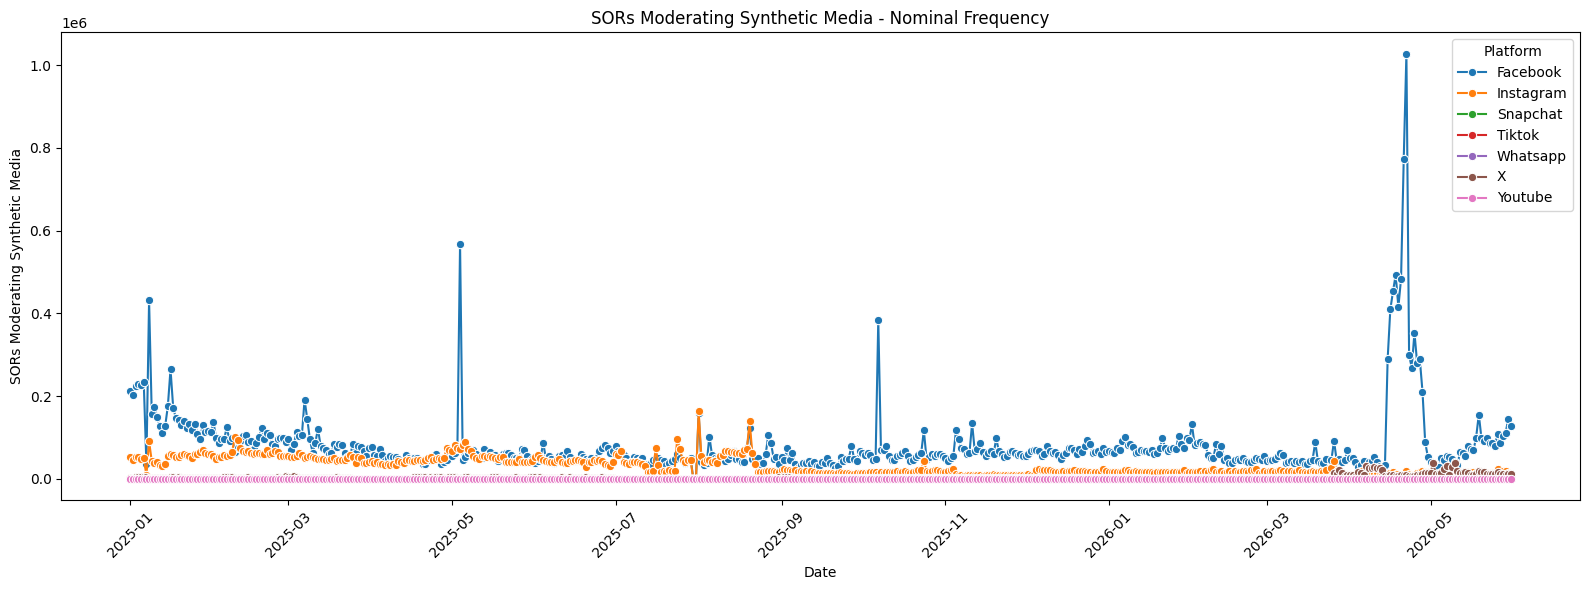

<Figure size 640x480 with 0 Axes>

In [39]:
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# Visualisations ----
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# Visualise: Synthetic Media of all Platforms
plt.figure(figsize=(16,6))

sns.lineplot(data = df_cut, x = "date", y = "content_type_synthetic_media",
             hue = "platform", marker = "o")

plt.xlabel("Date")
plt.ylabel("SORs Moderating Synthetic Media")
plt.title("SORs Moderating Synthetic Media - Nominal Frequency")
plt.legend(title = "Platform")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Export
plt.savefig(f"{path_out}03_rq1_quant_1_synthetic_media_nominal_freq.pdf", bbox_inches="tight")

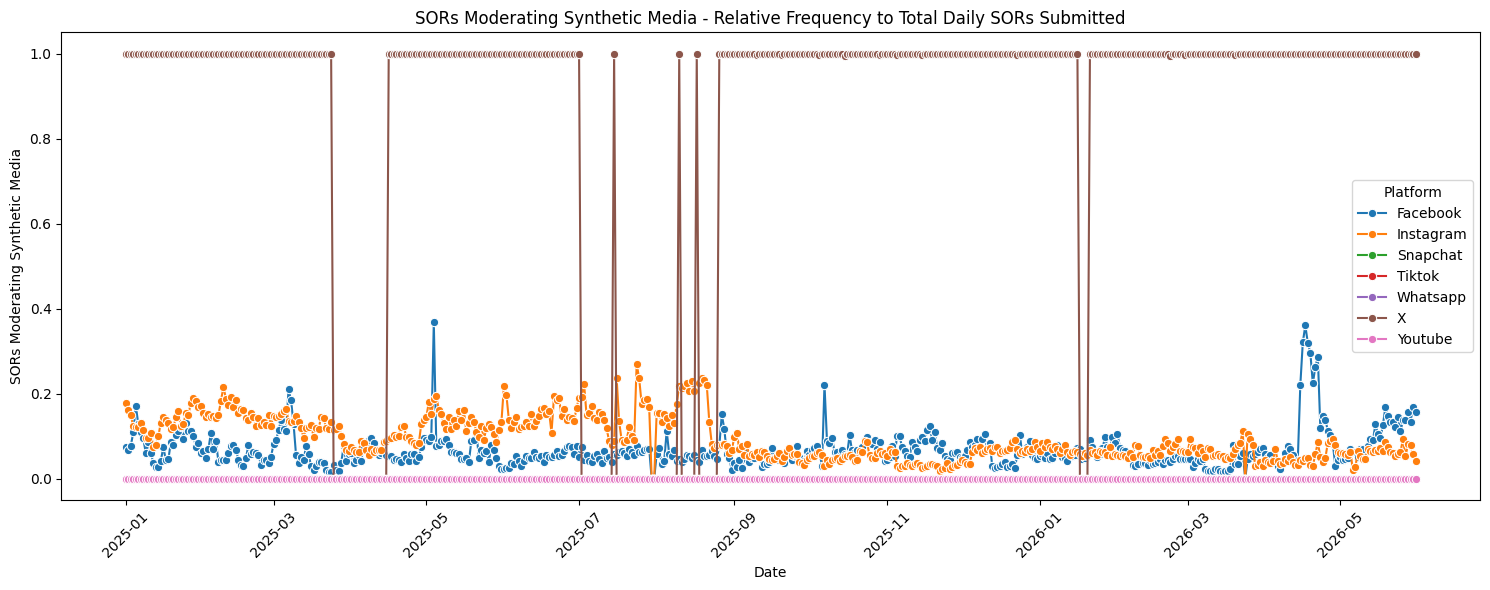

<Figure size 640x480 with 0 Axes>

In [40]:
# Visualise Relative to Total Number of SORs Reported
plt.figure(figsize=(15,6))

sns.lineplot(data = df_cut, x = "date", y = "syn_rel_to_total",
             hue = "platform", marker = "o")

plt.xlabel("Date")
plt.ylabel("SORs Moderating Synthetic Media")
plt.title("SORs Moderating Synthetic Media - Relative Frequency to Total Daily SORs Submitted")
plt.legend(title = "Platform")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Export
plt.savefig(f"{path_out}03_rq1_quant_2_synthetic_media_rel_to_total.pdf", bbox_inches="tight")

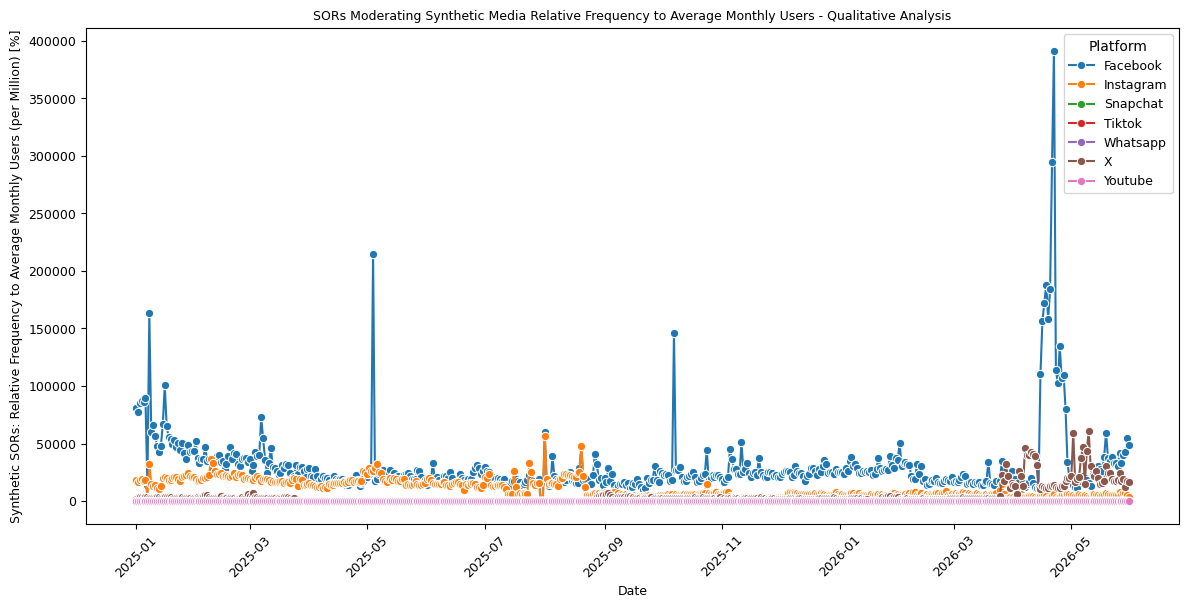

<Figure size 640x480 with 0 Axes>

In [43]:
### Relative Synthetic Media Moderation to Monthly Users per Million
plt.figure(figsize=(12,6))

sns.lineplot(data=df_cut, x="date", y="syn_rel_to_mil_users", hue="platform",
             marker="o")

plt.legend(title="Platform", fontsize=9)
plt.xticks(rotation=45, fontsize=9)
plt.yticks(fontsize=9)
plt.legend(title="Platform", fontsize=9)
plt.xlabel("Date", fontsize=9)
plt.tight_layout()
plt.ylabel("Synthetic SORs: Relative Frequency to Average Monthly Users (per Million) [%]", fontsize=9)
plt.title("SORs Moderating Synthetic Media Relative Frequency to Average Monthly Users - Qualitative Analysis", fontsize=9)
plt.show()

# Export
plt.savefig(f"{path_out}03_rq1_quant_3_synthetic_media_rel_to_users.pdf", bbox_inches="tight")

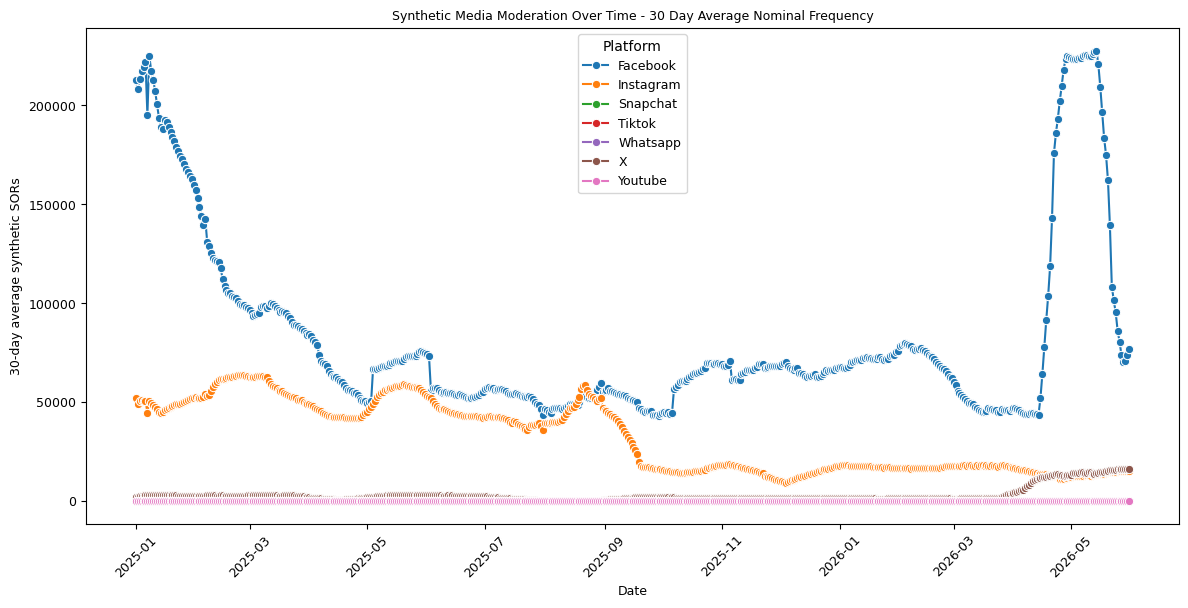

<Figure size 640x480 with 0 Axes>

In [44]:
### 30-Day Moving Average
plt.figure(figsize=(12,6))

sns.lineplot(data=df_cut, x="date", y="synthetic_ma30", hue="platform",
             marker="o")

plt.legend(title="Platform", fontsize=9)
plt.legend(title="Platform", fontsize=9)
plt.xlabel("Date", fontsize=9)
plt.xticks(rotation=45, fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.ylabel("30-day average synthetic SORs", fontsize=9)
plt.title("Synthetic Media Moderation Over Time - 30 Day Average Nominal Frequency", fontsize=9)
plt.show()

# Export
plt.savefig(f"{path_out}03_rq1_quant_4_synthetic_media_30_day_average.pdf", bbox_inches="tight")

In [45]:
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# Export Tables ----
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# Summary
summary.to_csv(f"{path_out}03_rq1_quant_5_summary.csv")

# Overall
overall.to_csv(f"{path_out}03_rq1_quant_6_overall.csv")

# Volatility
vol.to_csv(f"{path_out}03_rq1_quant_7_vol.csv")